In [2]:
# Stock Market Analysis: AAPL vs TSLA vs RELIANCE
#Analyzing stock performance using Python:
#- Returns
#- Volatility
#- Correlation

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data_aapl = yf.download("AAPL", period="1y")
data_tsla = yf.download("TSLA", period="1y")
data_rel = yf.download("RELIANCE.NS", period="1y")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [6]:
close_aapl = data_aapl['Close'].iloc[:, 0]
close_tsla = data_tsla['Close'].iloc[:, 0]
close_rel = data_rel['Close'].iloc[:, 0]

**Analysis Stock Price Trends**

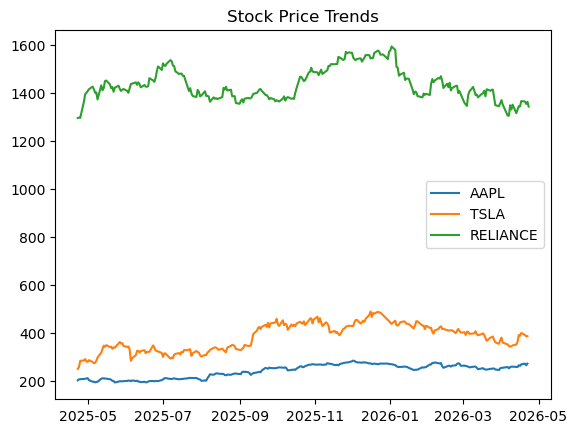

In [7]:
plt.figure()
plt.plot(close_aapl, label="AAPL")
plt.plot(close_tsla, label="TSLA")
plt.plot(close_rel, label="RELIANCE")
plt.legend()
plt.title("Stock Price Trends")
plt.show()

The differnce in the Price's is due to the currency differnce between Reliance and Apple,Tesla as the later two use USD and Reliance uses INR, along with this a few other reasons such as 
Number of shares issued
Stock splits
Company structure

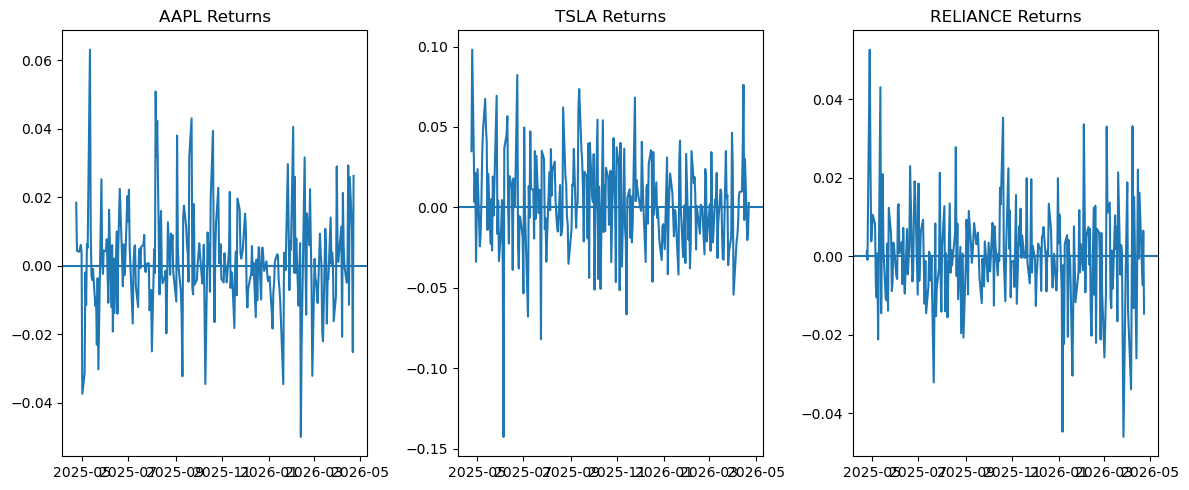

In [14]:
plt.figure(figsize=(12, 5))

# AAPL
plt.subplot(1, 3, 1)
plt.plot(returns_aapl)
plt.axhline(0)
plt.title("AAPL Returns")

# TSLA
plt.subplot(1, 3, 2)
plt.plot(returns_tsla)
plt.axhline(0)
plt.title("TSLA Returns")

# RELIANCE
plt.subplot(1, 3, 3)
plt.plot(returns_rel)
plt.axhline(0)
plt.title("RELIANCE Returns")

plt.tight_layout()
plt.show()

**Comaring returns over a year**

In [10]:
total_return_aapl = (close_aapl.iloc[-1] / close_aapl.iloc[0]) - 1
total_return_tsla = (close_tsla.iloc[-1] / close_tsla.iloc[0]) - 1
total_return_rel = (close_rel.iloc[-1] / close_rel.iloc[0]) - 1

print(f"AAPL: {total_return_aapl*100:.2f}%")
print(f"TSLA: {total_return_tsla*100:.2f}%")
print(f"RELIANCE: {total_return_rel*100:.2f}%")

AAPL: 34.10%
TSLA: 54.55%
RELIANCE: 3.66%


**Comparing Volatility**

In [11]:
vol_aapl = returns_aapl.dropna().std()
vol_tsla = returns_tsla.dropna().std()
vol_rel = returns_rel.dropna().std()

print(f"AAPL Volatility: {vol_aapl*100:.2f}%")
print(f"TSLA Volatility: {vol_tsla*100:.2f}%")
print(f"RELIANCE Volatility: {vol_rel*100:.2f}%")

AAPL Volatility: 1.48%
TSLA Volatility: 3.04%
RELIANCE Volatility: 1.28%


Tesla has been the most volatile this past year but also has given the best returns, this means Tesla has been  high risk high reward, meanwhile Apple has shown a great return with low volatility but, reliance has not shown great returns with low volatility.

**Normalised comparison**

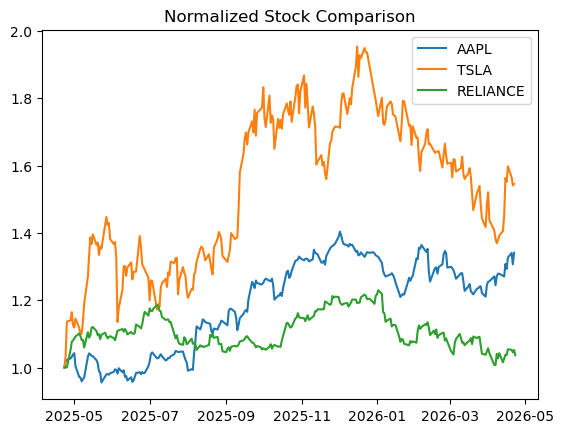

In [12]:
plt.figure()

plt.plot(close_aapl / close_aapl.iloc[0], label="AAPL")
plt.plot(close_tsla / close_tsla.iloc[0], label="TSLA")
plt.plot(close_rel / close_rel.iloc[0], label="RELIANCE")

plt.legend()
plt.title("Normalized Stock Comparison")
plt.show()

/var/folders/h_/z5j0lbq51tj21g1s38098xbw0000gn/T/ipykernel_72323/3923831999.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = combined.pct_change()


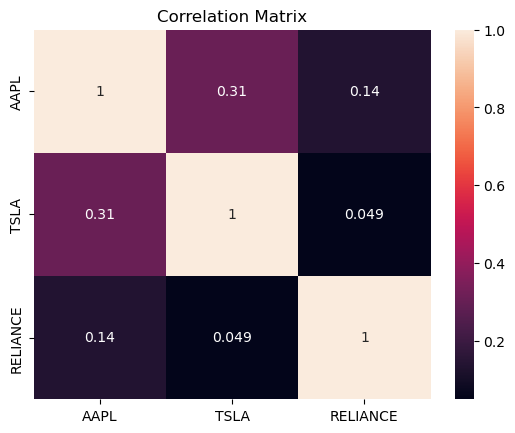

In [13]:
combined = pd.DataFrame({
    "AAPL": close_aapl,
    "TSLA": close_tsla,
    "RELIANCE": close_rel
})

returns = combined.pct_change()

sns.heatmap(returns.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

This heatmap shows the relative change of one stock with respect to another stock that is why the diagonal of the map shows 1,1,1 since the relative change of one stock to itself will be 1 itself

Tesla showed the highest returns (~54%)but also exhibited the highest volatility, indicating higher risk.
Apple provided moderate returns (~34%) with lower volatility, making it a more stable investment.
Reliance showed lower correlation with both US stocks, suggesting diversification benefits.

This analysis highlights the trade-off between risk and return and the importance of diversification in portfolio management.